In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 무시 설정
import warnings
warnings.filterwarnings(action='ignore')

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 전국 노인복지시설 현황(2020-2024)

In [5]:
df00 = pd.read_csv('./전국_노인복지시설_현황_.csv', header=[0,1])
df00

시설별(1)      시설별(2)     2020              2021              2022  \
         시설별(1)      시설별(2) 시설수 (개소) 입소정원 (명) 시설수 (개소) 입소정원 (명) 시설수 (개소)   
0            총계          소계    82544   297167    85228   321500    89698   
1      노인주거복지시설          소계      352    20497      337    19383      308   
2           NaN        양로시설      209    11619      192     9962      180   
3           NaN    노인공동생활가정      107      953      107      930       89   
4           NaN      노인복지주택       36     7925       38     8491       39   
5      노인의료복지시설          소계     5725   203075     5821   214683     6069   
6           NaN      노인요양시설     3844   186289     4057   199134     4346   
7           NaN  노인요양공동생활가정     1881    16786     1764    15549     1723   
8      노인여가복지시설          소계    69005        0    68823        0    69786   
9           NaN       노인복지관      398        0      357        0      366   
10          NaN         경로당    67316        0    67211        0    68180   
11          NaN        노인교실     1291        0     1255        0     1240   
12     재가노인복지시설          소계     7212    73595     9984    87434    13272   
13          NaN     방문요양서비스     2656        0     4156        0     5808   
14          NaN    주야간보호서비스     2321    72639     2618    86921     3035   
15          NaN     단기보호서비스       73      956       69      513       70   
16          NaN     방문목욕서비스     1596        0     2415        0     3394   
17          NaN     방문간호서비스       95        0      158        0      234   
18          NaN   복지용구지원서비스       86        0      208        0      368   
19          NaN   재가노인지원서비스      385        0      360        0      363   
20     노인보호전문기관          소계       35        0       37        0       37   
21    노인일자리지원기관          소계      196        0      206        0      206   
22  학대피해노인 전용쉼터          소계       19        0       20        0       20   

                2023              2024           
   입소정원 (명) 시설수 (개소) 입소정원 (명) 시설수 (개소) 입소정원 (명)  
0    358447    93056   387391    96430   412917  
1     19355      297    19369      281    19412  
2      9752      175     9653      166     9567  
3       763       82      710       72      614  
4      8840       40     9006       43     9231  
5    232235     6139   242974     6195   250898  
6    216784     4525   228495     4640   236365  
7     15451     1614    14479     1555    14533  
8         0    70455        0    70935        0  
9         0      438        0      454        0  
10        0    68792        0    69260        0  
11        0     1225        0     1221        0  
12   106857    15896   125048    18745   142607  
13        0     7192        0     8668        0  
14   106394     3397   124402     3790   142352  
15      463       60      646       60      255  
16        0     4070        0     4794        0  
17        0      295        0      376        0  
18        0      540        0      718        0  
19        0      342        0      339        0  
20        0       38        0       39        0  
21        0      211        0      215        0  
22        0       20        0       20        0

## 주제선정배경 그래프

In [6]:
df00 = pd.read_csv('./주제선정배경_그래프.csv')
df00

,구분,지역명,대상인구,제공시설,인구천명당시설
0,광역,광주,521268,2044,3.9
1,광역,대전,522597,1805,3.5
2,광역,전국,19449513,58458,3.0
3,광역,대구,918439,2350,2.6
4,광역,부산,1326962,2864,2.2
5,기초,경기동두천,38500,181,4.7
6,기초,경기시흥,168043,772,4.6
7,기초,전국,19449513,58458,3.0
8,기초,부산금정,87952,154,1.8
9,기초,부산서구,46328,72,1.6


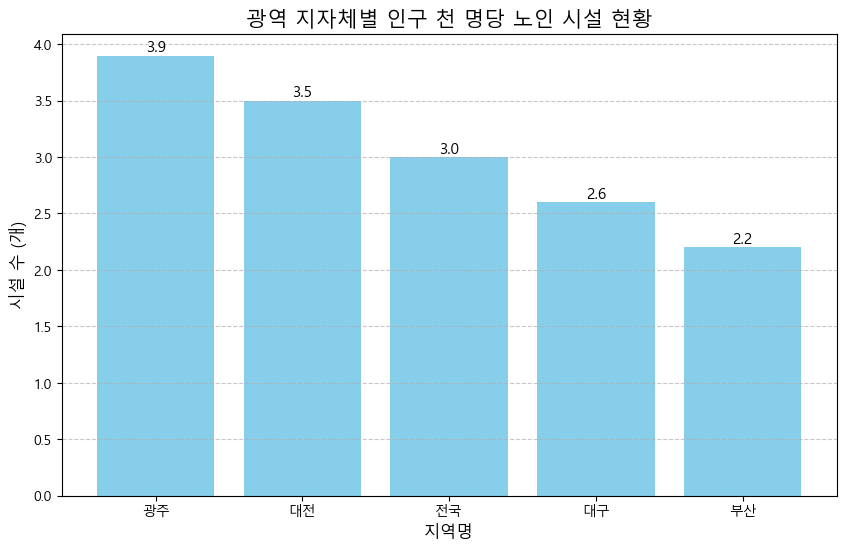

In [7]:
import matplotlib.pyplot as plt

# 1. '광역' 데이터만 필터링
df_metropolitan = df00[df00['구분'] == '광역'].copy()

# 2. 막대 그래프 그리기
plt.figure(figsize=(10, 6))
bars = plt.bar(df_metropolitan['지역명'], df_metropolitan['인구천명당시설'], color='skyblue')

# 3. 그래프 꾸미기 (한글 깨짐 방지 설정이 되어있어야 합니다)
plt.title('광역 지자체별 인구 천 명당 노인 시설 현황', fontsize=15)
plt.xlabel('지역명', fontsize=12)
plt.ylabel('시설 수 (개)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 각 막대 위에 수치 표시 (선택 사항)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height}', 
             ha='center', va='bottom', fontsize=11)

plt.show()

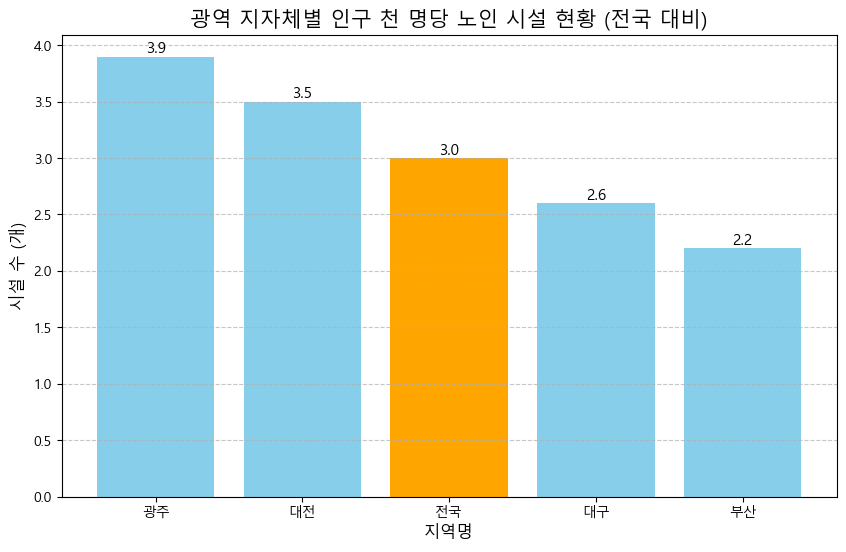

In [9]:
import matplotlib.pyplot as plt

# 1. '광역' 데이터만 필터링
df_metropolitan = df00[df00['구분'] == '광역'].copy()

# 2. 지역명에 따라 색상 리스트 생성
# '전국'은 강조색(예: 주황색), 나머지는 기본색(예: 하늘색) 설정
colors = ['orange' if name == '전국' else 'skyblue' for name in df_metropolitan['지역명']]

# 3. 막대 그래프 그리기
plt.figure(figsize=(10, 6))
bars = plt.bar(df_metropolitan['지역명'], df_metropolitan['인구천명당시설'], color=colors)

# 4. 그래프 꾸미기
plt.title('광역 지자체별 인구 천 명당 노인 시설 현황 (전국 대비)', fontsize=15)
plt.xlabel('지역명', fontsize=12)
plt.ylabel('시설 수 (개)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height}', 
             ha='center', va='bottom', fontsize=11, 
             fontweight='bold' if bar.get_facecolor() == (1.0, 0.647, 0.0, 1.0) else 'normal') # 주황색인 경우 볼드체

plt.show()

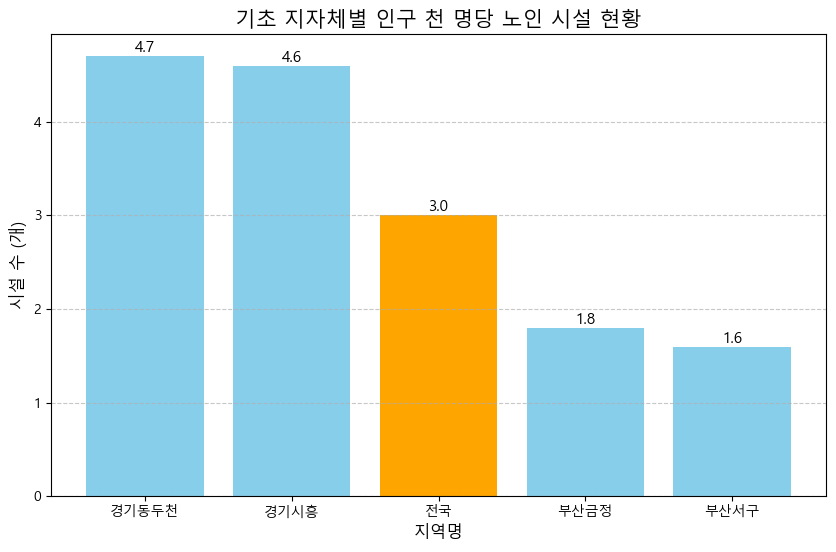

In [13]:
import matplotlib.pyplot as plt

# 1. '기초' 데이터만 필터링
df_basic = df00[df00['구분'] == '기초'].copy()

# 2. 지역명에 따라 색상 리스트 생성 (전국은 주황색, 나머지는 연두색 계열 추천)
colors = ['orange' if name == '전국' else 'skyblue' for name in df_basic['지역명']]

# 3. 막대 그래프 그리기
plt.figure(figsize=(10, 6))
bars = plt.bar(df_basic['지역명'], df_basic['인구천명당시설'], color=colors)

# 4. 그래프 꾸미기
plt.title('기초 지자체별 인구 천 명당 노인 시설 현황', fontsize=15)
plt.xlabel('지역명', fontsize=12)
plt.ylabel('시설 수 (개)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height}', 
             ha='center', va='bottom', fontsize=11)

plt.show()

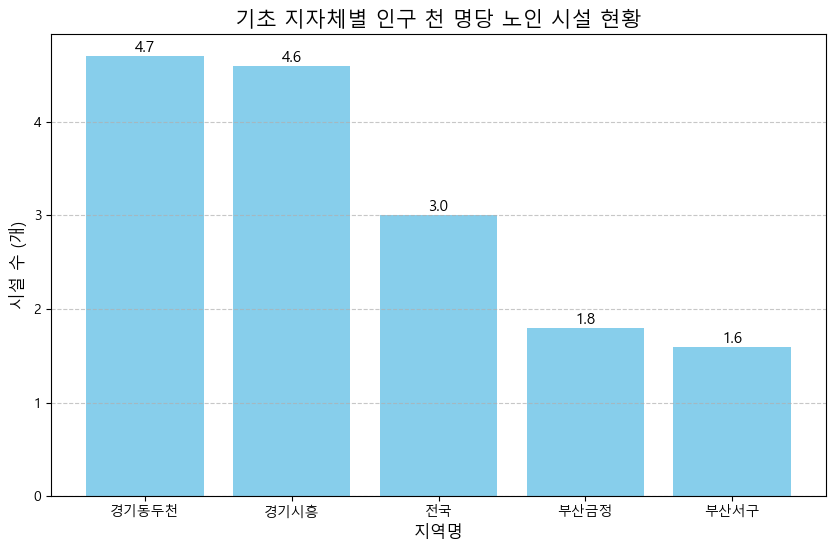

In [11]:
import matplotlib.pyplot as plt

# 1. '기초' 데이터만 필터링
df_basic = df00[df00['구분'] == '기초'].copy()

# 2. 막대 그래프 그리기 (모든 막대를 같은 색상으로 설정)
plt.figure(figsize=(10, 6))
# 'skyblue' 대신 김은세님이 선호하시는 다른 색상(예: 'lightgreen', 'steelblue')으로 변경 가능합니다.
bars = plt.bar(df_basic['지역명'], df_basic['인구천명당시설'], color='skyblue')

# 3. 그래프 꾸미기
plt.title('기초 지자체별 인구 천 명당 노인 시설 현황', fontsize=15)
plt.xlabel('지역명', fontsize=12)
plt.ylabel('시설 수 (개)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 각 막대 위에 수치 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{height}', 
             ha='center', va='bottom', fontsize=11)

plt.show()